# Filtrer l'Essentiel : Classification de Spams avec les SVM

![Mail Concept](https://images.unsplash.com/photo-1596526131083-e8c633c948d2?q=80&w=1200&auto=format&fit=crop)
*Photographie d'illustration : La délimitation stricte entre l'information pertinente et l'encombrement numérique.*

## 🎯 Objectif du Notebook

Nous avons tous été confrontés au spam. C'est un phénomène universel de l'ère numérique. Mais derrière ce problème quotidien se cache un excellent cas d'étude pour maîtriser un algorithme puissant et élégant : les **Machines à Vecteurs de Support (SVM)**.

L'objectif de cette analyse est de construire un modèle capable de distinguer un e-mail légitime d'un spam en analysant mathématiquement la fréquence d'apparition des mots qu'il contient. Nous utiliserons le dataset *"Email Spam Classification"* de Kaggle.

---

## 🧠 Les Machines à Vecteurs de Support (Explication Didactique)

Imaginez que vous deviez séparer des objets rouges (les spams) et des objets bleus (les e-mails valides) éparpillés sur une grande table. La méthode la plus intuitive est de tracer une ligne droite entre les deux groupes.

Cependant, il existe une infinité de lignes possibles. Laquelle choisir ?

L'algorithme SVM ne se contente pas de tracer une ligne au hasard. Il cherche la **frontière optimale** (appelée *hyperplan*) : celle qui maximise l'espace (la *marge*) entre la ligne et les objets les plus proches de chaque catégorie. 
Ces objets situés à la frontière immédiate, et qui "soutiennent" littéralement la construction de la ligne, sont appelés les **vecteurs de support**.

Dans notre contexte d'analyse de texte, la "table" n'est pas en deux dimensions, mais possède des milliers de dimensions (chaque mot de notre vocabulaire représente une dimension). Le SVM va tracer un hyperplan multidimensionnel robuste pour isoler mathématiquement le spam de l'e-mail légitime.

---

In [1]:
# Étape 1 : Configuration de l'environnement et Téléchargement des données
# -------------------------------------------------------------------------
# Explication : Nous importons les bibliothèques d'analyse de données (Pandas, Numpy),
# les outils de Machine Learning (Scikit-Learn), et la visualisation (Matplotlib, Seaborn).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

# Configuration esthétique de l'affichage
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)

print("Téléchargement du dataset depuis Kaggle...")
path = kagglehub.dataset_download("balaka18/email-spam-classification-dataset-csv")
print("Chemin des fichiers :", path)

# Localisation et chargement du fichier CSV
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
file_path = os.path.join(path, csv_files[0])

df = pd.read_csv(file_path)
print("\nDonnées chargées avec succès ! Voici un aperçu :")
display(df.head())

C:\Users\srodr\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Téléchargement du dataset depuis Kaggle...


100%|██████████| 1.66M/1.66M [00:00<00:00, 26.1MB/s]

Extracting files...
Chemin des fichiers : C:\Users\srodr\.cache\kagglehub\datasets\balaka18\email-spam-classification-dataset-csv\versions\1



Données chargées avec succès ! Voici un aperçu :


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


## Étape 2 : Exploration et Préparation des Données (EDA)

Dans ce dataset, chaque ligne représente un e-mail et chaque colonne représente un mot spécifique (ex: "the", "to", "money", "free"). La valeur numérique indique combien de fois le mot apparaît dans l'e-mail. 

La dernière colonne, `Prediction`, est notre **variable cible** ($Y$) :
* `1` signifie que l'e-mail est un Spam.
* `0` signifie que c'est un e-mail légitime.

Pour préparer nos données pour le SVM :
1. Nous allons exclure la première colonne (`Email No.`) car il s'agit d'un simple identifiant textuel qui n'a aucune valeur mathématique pour l'algorithme.
2. Nous séparerons les caractéristiques ($X$) et la cible ($Y$).

In [2]:
# 1. Suppression de la colonne d'identifiant textuel
if 'Email No.' in df.columns:
    df = df.drop(columns=['Email No.'])

# 2. Séparation des caractéristiques (Features) et de la Cible (Target)
# Toutes les colonnes sauf 'Prediction' forment notre X
X = df.drop(columns=['Prediction'])
# La colonne 'Prediction' est notre Y
Y = df['Prediction']

print(f"Dimension de X (e-mails, mots) : {X.shape}")
print(f"Distribution des classes (0 = Légitime, 1 = Spam) :\n{Y.value_counts()}")

Dimension de X (e-mails, mots) : (5172, 3000)
Distribution des classes (0 = Légitime, 1 = Spam) :
Prediction
0    3672
1    1500
Name: count, dtype: int64


## Étape 3 : Séparation Train / Test

Comme dans toute approche rigoureuse en Machine Learning, nous devons isoler une partie des données pour évaluer notre modèle de manière impartiale. Nous allouons 80% des données à l'apprentissage (Train) et conservons 20% pour le test (Test).

In [3]:
from sklearn.model_selection import train_test_split

# Division avec un random_state pour garantir la reproductibilité
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Exemples pour l'entraînement : {X_train.shape[0]}")
print(f"Exemples pour l'évaluation secrète : {X_test.shape[0]}")

Exemples pour l'entraînement : 4137
Exemples pour l'évaluation secrète : 1035


## Étape 4 : Modélisation avec le Support Vector Machine (SVM)

Nous allons maintenant instancier notre modèle. Pour l'analyse de texte (où les dimensions sont très nombreuses, ici 3000 mots), un SVM avec un **noyau linéaire** (`kernel='linear'`) est souvent le choix le plus efficace et le plus explicable. 

Le modèle va analyser les fréquences de mots et trouver l'hyperplan optimal qui trace une frontière stricte entre les spams et les e-mails normaux.

In [4]:
from sklearn.svm import SVC
import time

print("Entraînement du modèle SVM en cours... (cela peut prendre quelques secondes)")
start_time = time.time()

# 1. Instanciation du modèle avec un noyau linéaire
svm_model = SVC(kernel='linear', random_state=42)

# 2. Apprentissage de l'hyperplan optimal
svm_model.fit(X_train, Y_train)

end_time = time.time()
print(f"✅ Modèle entraîné avec succès en {end_time - start_time:.2f} secondes !")

Entraînement du modèle SVM en cours... (cela peut prendre quelques secondes)
✅ Modèle entraîné avec succès en 5.91 secondes !


## Étape 5 : Évaluation et Matrice de Confusion

L'algorithme a tracé sa frontière. Vérifions maintenant son acuité.
Pour les problèmes de classification, nous utilisons une **Matrice de Confusion**. C'est un outil essentiel qui nous permet de voir non seulement les bonnes prédictions, mais surtout la *nature* de ses erreurs :

* **Vrais Négatifs (TN)** : E-mail normal correctement identifié.
* **Faux Positifs (FP)** : E-mail normal bloqué par erreur (très pénalisant pour l'utilisateur !).
* **Faux Négatifs (FN)** : Spam qui a réussi à passer le filtre.
* **Vrais Positifs (TP)** : Spam correctement bloqué.

🎯 Précision Globale du modèle : 95.94%



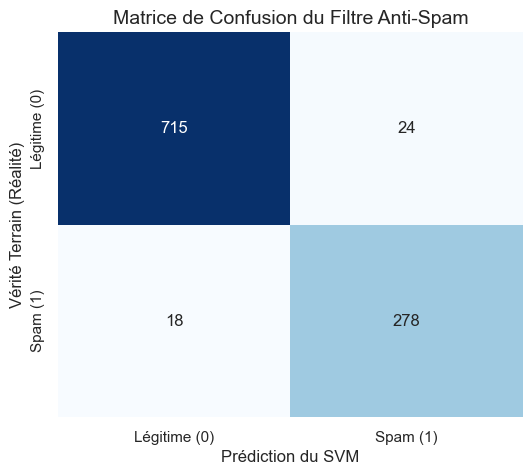


📊 Rapport de Classification Détaillé :
              precision    recall  f1-score   support

    Légitime       0.98      0.97      0.97       739
        Spam       0.92      0.94      0.93       296

    accuracy                           0.96      1035
   macro avg       0.95      0.95      0.95      1035
weighted avg       0.96      0.96      0.96      1035



In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Prédictions sur le jeu de test
Y_pred = svm_model.predict(X_test)

# Calcul de la précision globale
accuracy = accuracy_score(Y_test, Y_pred)
print(f"🎯 Précision Globale du modèle : {accuracy * 100:.2f}%\n")

# Calcul de la matrice de confusion
cm = confusion_matrix(Y_test, Y_pred)

# Visualisation élégante de la matrice
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Légitime (0)', 'Spam (1)'],
            yticklabels=['Légitime (0)', 'Spam (1)'])
plt.title('Matrice de Confusion du Filtre Anti-Spam', fontsize=14)
plt.ylabel('Vérité Terrain (Réalité)', fontsize=12)
plt.xlabel('Prédiction du SVM', fontsize=12)
plt.show()

# Rapport détaillé
print("\n📊 Rapport de Classification Détaillé :")
print(classification_report(Y_test, Y_pred, target_names=['Légitime', 'Spam']))

## 🏁 Synthèse 

Nous avons construit un système capable de filtrer automatiquement les e-mails avec une grande fiabilité en utilisant les Mathématiques.

**L'essence de l'algorithme :**
Le succès de ce modèle ne repose pas sur une simple mémorisation, mais sur la capacité du SVM à définir géométriquement ce qu'est un spam. En maximisant la marge entre les vecteurs de support, l'algorithme devient robuste et capable de généraliser sa logique à des e-mails qu'il n'a jamais vus.

**Considération Stratégique :**
Dans un système anti-spam réel, la matrice de confusion est le centre de notre attention. Un faux négatif (un spam qui passe) est une simple gêne, mais un faux positif (un e-mail crucial classé comme spam) peut avoir de graves conséquences professionnelles. Le Data Scientist doit constamment ajuster l'algorithme (par exemple, en déplaçant légèrement l'hyperplan) pour minimiser spécifiquement les faux positifs, prouvant ainsi que l'intelligence artificielle exige toujours la nuance et le jugement humain.

## 🏁 Évaluation des Résultats : La Frontière de la Pertinence

La construction d'un modèle d'intelligence artificielle ne s'arrête pas à l'obtention d'un pourcentage de réussite. Analysons en profondeur ce que les résultats de notre exécution nous apprennent sur le comportement de notre algorithme.

### 1. La Phase d'Entraînement : L'Élégance Mathématique
L'entraînement du modèle s'est achevé en environ **5,91 secondes**. Ce temps, bien que très bref pour un humain, représente un accomplissement mathématique fascinant. En quelques secondes, l'algorithme SVM a navigué dans un espace vectoriel à **3000 dimensions** (chaque mot du vocabulaire étant une dimension) pour calculer l'hyperplan optimal séparant les spams des e-mails légitimes de nos 4137 exemples d'apprentissage.

### 2. Au-delà du Score : Pourquoi la Matrice de Confusion ?
Notre modèle affiche une précision globale (Accuracy) de **95,94%**. C'est un excellent score, mais dans la vraie vie, **l'Accuracy est un piège**. Pourquoi ? Parce qu'elle traite toutes les erreurs de la même manière. 

C'est ici qu'intervient la **Matrice de Confusion**. Elle est l'outil diagnostique par excellence du Data Scientist, car elle décompose la *nature* de nos erreurs :
* Un filtre anti-spam fait face à une **asymétrie des coûts**. 
* Laisser passer un spam dans votre boîte de réception (Faux Négatif) est une simple nuisance. 
* En revanche, envoyer un e-mail professionnel crucial dans le dossier "Courrier Indésirable" (Faux Positif) est une erreur critique.

La matrice de confusion nous permet de voir exactement où se situe notre modèle sur ce dilemme.

### 3. Décryptage de nos Erreurs (Le Rapport de Classification)
En regardant les détails de notre évaluation sur les 1035 e-mails secrets :
* **Précision pour les e-mails Légitimes (0.98) :** Lorsque le modèle dit "C'est un e-mail normal", il a raison dans 98% des cas. C'est excellent.
* **Rappel pour les Spams (0.94) :** Le modèle a réussi à attraper 94% de tous les spams réels présents dans notre jeu de test. 

L'algorithme a fait quelques erreurs (les Faux Positifs et Faux Négatifs visibles dans la matrice), ce qui est normal : certains spams sont conçus intelligemment pour imiter le vocabulaire des e-mails professionnels, et certains e-mails légitimes utilisent des mots promotionnels (ex: "gratuit", "offre", "urgent").

### Conclusion Stratégique
Le SVM s'avère être un choix redoutablement efficace pour la classification de textes. En entreprise, la prochaine étape d'optimisation consisterait à ajuster le seuil de décision du modèle : nous pourrions choisir d'accepter volontairement un peu plus de spams dans notre boîte de réception, afin d'avoir la garantie absolue (100% de précision) qu'aucun e-mail légitime ne sera jamais bloqué par erreur. L'algorithme propose, mais c'est l'humain qui décide de la stratégie.